# **Import Statements**

In [4]:
root = "C:\\Users\\saman\\Documents\\Github\\Magnetic-Levitation\\"

import numpy as np
import matplotlib.pyplot as plt

from utils.boundary_disk import Cylinder



%load_ext autoreload
%autoreload 2
plt.style.use(root + "style.mplstyle")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# **Von Karman Rotating Disk Problem**

BVP solved successfully!


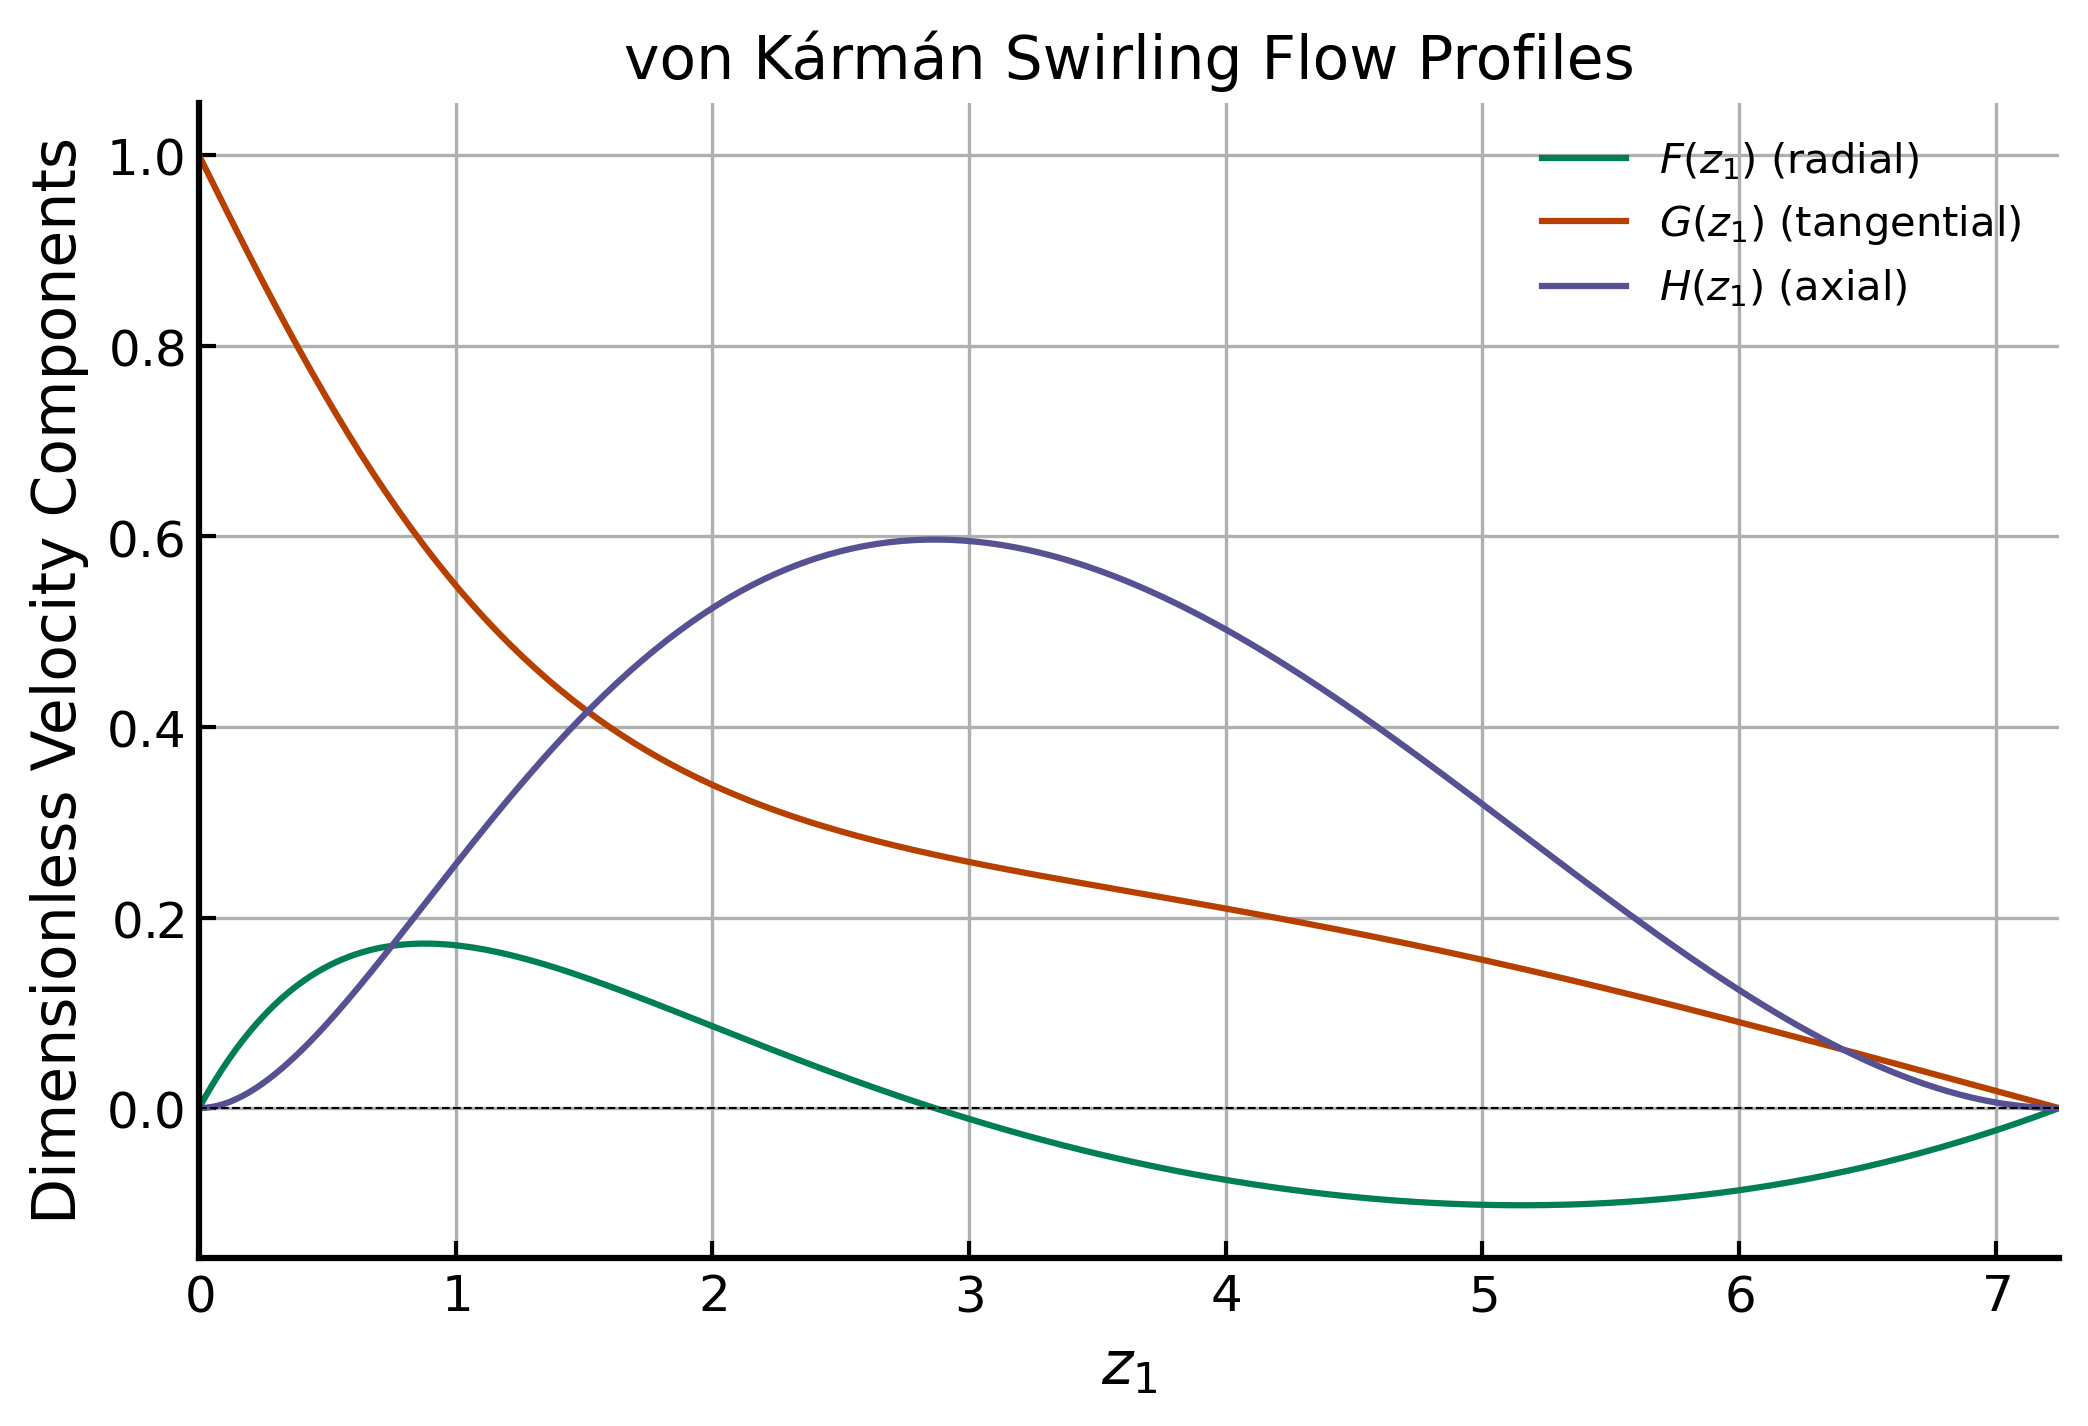

In [ ]:


def von_karman_ode(z, y, p):
    K = p[0]
    F, F_prime, G, G_prime, H = y
    
    
    dF = F_prime
    dF_prime = F**2 - G**2 + F_prime * H + K**2
    dG = G_prime
    dG_prime = 2 * F * G + G_prime * H
    dH = -2 * F
    
    return np.vstack((dF, dF_prime, dG, dG_prime, dH))

# boundary conditions
def bc(ya, yb, p):
    # ya corresponds to z_1 = 0
    # yb corresponds to z_1 = s sqrt(omega/nu)
    # p is for unfixed constants, but is unused

    #return residuals
    return np.array([
        ya[0] - 0.0,  # F(0) = 0
        ya[2] - 1.0,  # G(0) = 1
        ya[4] - 0.0,  # H(0) = 0
        yb[0] - 0.0,  # F(z(s)) = 0
        yb[2] - 0.0,  # G(z(s)) = 0
        yb[4] - 0.0   # H((s))
    ])

# Setup mesh/
Omega = 1000 #angular velocity in rpm 
mu = 1.795e-5 #viscosity of the fluid
s = 0.003*np.sqrt(Omega*2*np.pi/(60*mu))
z = np.linspace(0, s, 100)

# Initial guess for state variables
y_guess = np.zeros((5, z.size))
y_guess[0] = 0.2 * z * np.exp(-z) # F guess
y_guess[2] = np.exp(-z)            # G guess
y_guess[4] = -0.5 * z              # H guess

p_guess = [s]

# 4. Solve BVP
sol = solve_bvp(von_karman_ode, bc, z, y_guess, p_guess)

if sol.success:
    print("BVP solved successfully!")
    
    # 5. Plot the solution
    z_plot = np.linspace(0, s, 300)
    y_plot = sol.sol(z_plot)

    plt.figure(figsize=(8, 5))
    plt.plot(z_plot, y_plot[0], label=r'$F(z_1)$ (radial)')
    plt.plot(z_plot, y_plot[2], label=r'$G(z_1)$ (tangential)')
    plt.plot(z_plot, -y_plot[4], label=r'$H(z_1)$ (axial)')
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.xlim(0, s)
    plt.xlabel(r'$z_1$')
    plt.ylabel('Dimensionless Velocity Components')
    plt.title('von Kármán Swirling Flow Profiles')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("BVP solver failed to converge:", sol.message)

# **Normalized Dissipation v. Normalized Gap Distance**

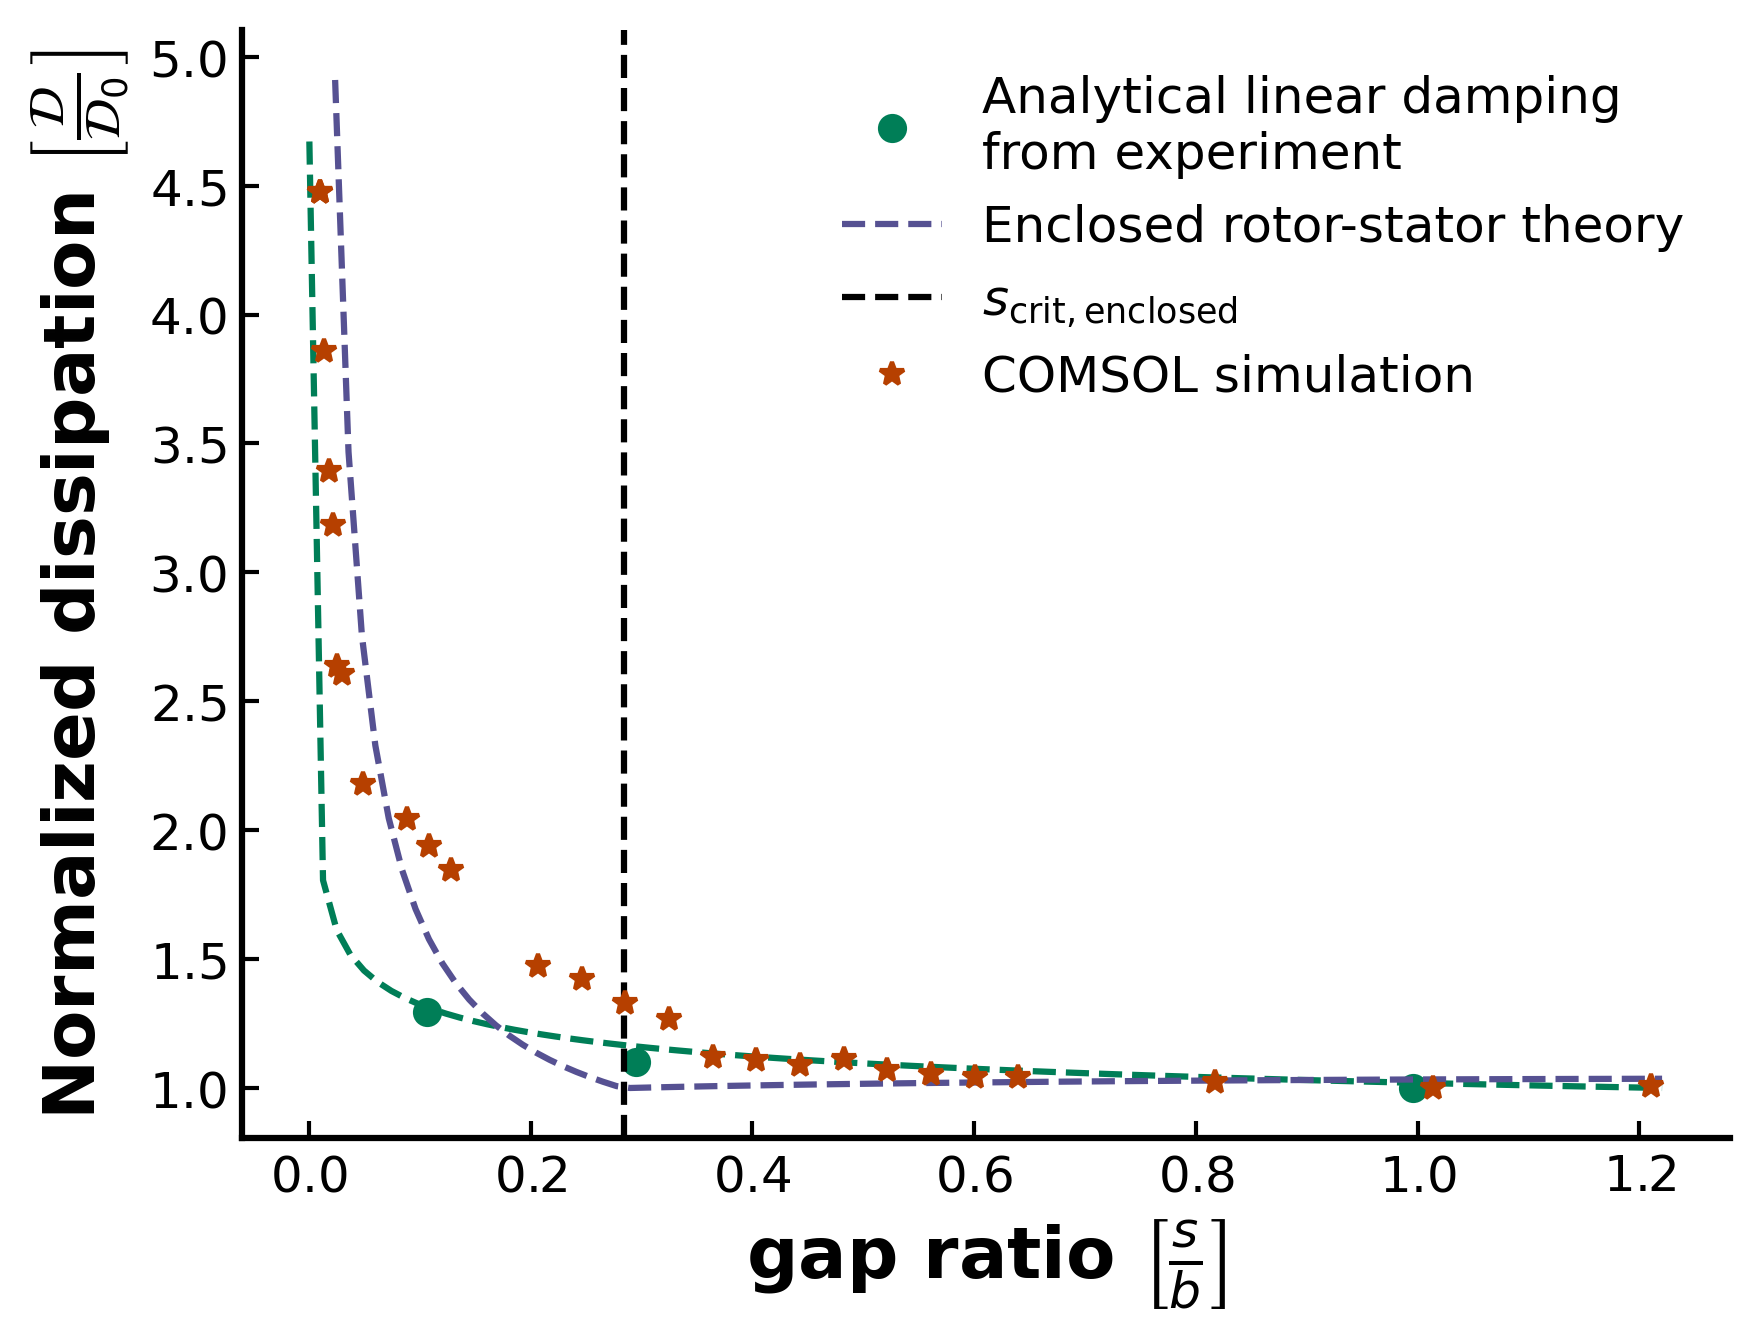

In [23]:
cylinder = Cylinder( 
            b = 0.00254,  # radius in meters
            rho = 7500, # cylinder density in kg/m^3
            Omega = 1000, # angular velocity in rpm 
            rho_f = 1.226, # density of the fluid in kg/m^3
            mu = 1.795e-5, # viscosity of the fluid in pascal seconds
            elle = 0.0105, # total gap distance in meters
            L = 0.003175 # length of the cylinder in meters
        )

gap_exp = np.asarray([0.00027, 0.00075, 0.00253]) #in meters
tau_exp = np.asarray([85, 100, 110]) #in seconds

#Linear Fit
s_array_lin, dissipation_lin, dissipation_fit_lin = cylinder.linear_damping(
    gap = gap_exp, #in meters
    tau = tau_exp, # in seconds
    start = 1e-6, #in meters
    stop = 0.0031 # in meters
)

#Enclosed Rotor-Stator Fit
s_array_ers, dissipation_ers, s_crit_ers = cylinder.enclosed_rotor_stator(
    gap = gap_exp, #in meters
    tau = tau_exp, # in seconds
    start = 60e-6, #in meters
    stop = 0.0031 # in meters
)

#COMSOL Simulation
gap_COMSOL = 2.075  + np.asarray([-2.05, -1.95, -1.85, -1.75, -1.55, -1.45, -1.35, -1.25, -1.15, -1.05, -0.9499999999999997, -0.8499999999999996, -0.7499999999999998,
                                    -0.6499999999999997, -0.5499999999999998, -0.4499999999999997, -2.05, -2.04, -2.03, -2.02, -2.01, -2, -1.8, 1, 0.5, 0]) # in mm
gap_COMSOL = gap_COMSOL/1000 #convert from mm to meters
dissipation_COMSOL = np.asarray([7.276218039755276e-08, 3.54147777132402e-08, 3.319989813145014e-08, 2.999256618224352e-08, 2.397974446357202e-08, 
                                    2.315700597492343e-08, 2.161300607312653e-08, 2.059531916586093e-08, 1.818476156508958e-08, 1.805479547545832e-08,
                                    1.770094325751496e-08, 1.810964892360439e-08, 1.738181837805184e-08, 1.713697045790447e-08, 1.696140911262177e-08,
                                    1.69594542751747e-08, 7.276218039755276e-08, 6.27325979686784e-08, 5.517541944117902e-08, 5.178201911733897e-08, 
                                    4.28650162841852e-08, 4.237478948935986e-08, 3.154069141653727e-08, 1.639943102219439e-08, 1.625977604031675e-08, 1.660765723313549e-08]) #in Watts/m^2

'''
Plotting
'''

# Linear Fit
plt.plot(s_array_lin/cylinder.b, dissipation_fit_lin/np.min(dissipation_fit_lin), linestyle = '--', c = 'C0')
plt.plot(gap_exp/cylinder.b, dissipation_lin/np.min(dissipation_lin), linestyle = '', marker = 'o', label = 'Analytical linear damping \nfrom experiment', c = 'C0')

#Enclosed Rotor-Stator
plt.plot(s_array_ers/cylinder.b, dissipation_ers/np.min(dissipation_ers), linestyle = '--', label = 'Enclosed rotor-stator theory', c = 'C2')
plt.axvline(x = s_crit_ers/cylinder.b, c = 'black', linestyle = '--', label = r'$s_\mathrm{crit, enclosed}$')

# COMSOL
plt.plot(gap_COMSOL/cylinder.b, dissipation_COMSOL/np.min(dissipation_COMSOL), linestyle = '', marker = '*', label = 'COMSOL simulation', c = 'C1')

plt.xlabel(r"gap ratio $\left[\frac{s}{b} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.ylabel(r"Normalized dissipation $\left[\frac{\mathcal{D}}{\mathcal{D}_0} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.legend(prop={'size': 12})
plt.show()

---